## EDA PROJECT ON E_COMMERCE_DATASET


#### Introdution

Exploratory Data Analysis (EDA) is a crucial step in the data analysis process that involves examining, summarizing, and visualizing datasets to understand their main characteristics. It helps in identifying patterns, detecting anomalies, testing assumptions, and gaining insights before applying advanced analytical or machine learning techniques.

In this project, a dataset containing multiple variables—both numerical and categorical—is analyzed to uncover meaningful relationships and trends. The dataset includes more than 1000 records along with various features such as string fields, numerical values, and date attributes, making it suitable for comprehensive analysis.

The primary objective of this EDA is to clean the data, handle missing values, and explore the structure of the dataset using statistical summaries and visualizations. Techniques such as distribution analysis, correlation studies, and trend analysis are applied to better understand the data and support decision-making.

Overall, this project demonstrates how raw data can be transformed into valuable insights through systematic exploration and visualization.

#### import the necessary libraries


In [2]:
# remove warning messages
import warnings
warnings.filterwarnings('ignore')

# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

#### import dataset

In [3]:
df=pd.read_csv("C:\datascience\projects\pandas_project\E_Commerce_Dataset.csv")

#### Display the first 5 rows of the dataset

In [4]:
print(df.head())

     Order_ID Customer_ID        Date  Age  Gender      City Product_Category  \
0  ORD_001337  CUST_01337  01-01-2023   27  Female     Bursa             Toys   
1  ORD_004885  CUST_04885  01-01-2023   42    Male     Konya             Toys   
2  ORD_004507  CUST_04507  01-01-2023   43  Female    Ankara             Food   
3  ORD_000645  CUST_00645  01-01-2023   32    Male  Istanbul      Electronics   
4  ORD_000690  CUST_00690  01-01-2023   40  Female  Istanbul           Sports   

   Unit_Price  Quantity  Discount sales  ...    Payment_Method Device_Type  \
0       54.28         1            0.00  ...        Debit Card      Mobile   
1      244.90         1            0.00  ...       Credit Card      Mobile   
2       48.15         5            0.00  ...       Credit Card      Mobile   
3      804.06         1          229.28  ...       Credit Card      Mobile   
4      755.61         5            0.00  ...  Cash on Delivery     Desktop   

  Session_Duration_Minutes  Pages_Viewed  Is

Display the last 5 rows of the dataset

In [5]:
(df.tail())

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount sales,...,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating,Discount_Percentage,Revenue_Without_Discount,Unnamed: 20
4995,ORD_001048,CUST_01048,26-03-2024,18,Female,Izmir,Beauty,130.35,1,27.30,...,Bank Transfer,Mobile,17,10,False,9,1,21%,130,NaN
4996,ORD_001051,CUST_01051,26-03-2024,27,Male,Adana,Beauty,71.55,1,0.00,...,Debit Card,Mobile,13,9,True,6,4,0%,72,NaN
4997,ORD_003543,CUST_03543,26-03-2024,45,Female,Antalya,Food,39.38,1,5.27,...,Digital Wallet,Mobile,38,10,True,5,4,13%,39,NaN
4998,ORD_004443,CUST_04443,26-03-2024,41,Female,Istanbul,Fashion,171.19,1,0.00,...,Credit Card,Mobile,20,12,True,5,4,0%,171,NaN
4999,ORD_000902,CUST_00902,26-03-2024,30,Female,Konya,Books,84.30,4,21.72,...,Debit Card,Desktop,8,9,True,5,5,6%,337,NaN


#### Data cleaning

In [6]:
# check whether there are missing values
print(df.isna().sum())

Order_ID                       0
Customer_ID                    0
Date                           0
Age                            0
Gender                         0
City                           0
Product_Category               0
Unit_Price                     0
Quantity                       0
Discount sales                 0
Total sales                    0
Payment_Method                 0
Device_Type                    0
Session_Duration_Minutes       0
Pages_Viewed                   0
Is_Returning_Customer          0
Delivery_Time_Days             0
Customer_Rating                0
Discount_Percentage            0
Revenue_Without_Discount       0
Unnamed: 20                 5000
dtype: int64


In [7]:
#Convert column name to standard type

df.columns=(df.columns
            .str.strip()
            .str.title()
            .str.replace(" ","_"))

In [8]:
#convert date column to date format

df['Date']=pd.to_datetime(df['Date'], dayfirst=True)

#### dropping null values


In [9]:
df = df.drop(columns='Unnamed:_20')
df.columns

Index(['Order_Id', 'Customer_Id', 'Date', 'Age', 'Gender', 'City',
       'Product_Category', 'Unit_Price', 'Quantity', 'Discount_Sales',
       'Total_Sales', 'Payment_Method', 'Device_Type',
       'Session_Duration_Minutes', 'Pages_Viewed', 'Is_Returning_Customer',
       'Delivery_Time_Days', 'Customer_Rating', 'Discount_Percentage',
       'Revenue_Without_Discount'],
      dtype='str')

#### Data understanding

In [10]:
# basic information about the dataset
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Order_Id                  5000 non-null   str           
 1   Customer_Id               5000 non-null   str           
 2   Date                      5000 non-null   datetime64[us]
 3   Age                       5000 non-null   int64         
 4   Gender                    5000 non-null   str           
 5   City                      5000 non-null   str           
 6   Product_Category          5000 non-null   str           
 7   Unit_Price                5000 non-null   float64       
 8   Quantity                  5000 non-null   int64         
 9   Discount_Sales            5000 non-null   float64       
 10  Total_Sales               5000 non-null   float64       
 11  Payment_Method            5000 non-null   str           
 12  Device_Type               5000 

In [11]:
# use summary statistics to understand distribution
print(df.describe())

                             Date          Age   Unit_Price     Quantity  \
count                        5000  5000.000000  5000.000000  5000.000000   
mean   2023-08-16 09:16:24.960000    35.032600   455.834120     2.220000   
min           2023-01-01 00:00:00    18.000000     5.180000     1.000000   
25%           2023-04-30 00:00:00    27.000000    76.587500     1.000000   
50%           2023-08-17 00:00:00    35.000000   182.950000     2.000000   
75%           2023-12-06 00:00:00    42.000000   513.930000     3.000000   
max           2024-03-26 00:00:00    75.000000  7159.450000     5.000000   
std                           NaN    11.080546   712.477209     1.398711   

       Discount_Sales   Total_Sales  Session_Duration_Minutes  Pages_Viewed  \
count     5000.000000   5000.000000                5000.00000    5000.00000   
mean        24.852804    983.108914                  14.57340       8.98420   
min          0.000000      7.870000                   1.00000       1.00000   

# Data analysis and Visualization

#### 1. What is the total no. of orders?

In [31]:
df.shape[0]

import matplotlib.pyplot as plt

total_orders = df.shape[0]
print('The total no. of order is: ' ,total_orders)



The total no. of order is:  5000


#### 2.What are the different product categories?

In [13]:
df['Product_Category'].unique()

<StringArray>
[         'Toys',          'Food',   'Electronics',        'Sports',
        'Beauty',       'Fashion', 'Home & Garden',         'Books']
Length: 8, dtype: str

#### 3.What is the average age of customers?

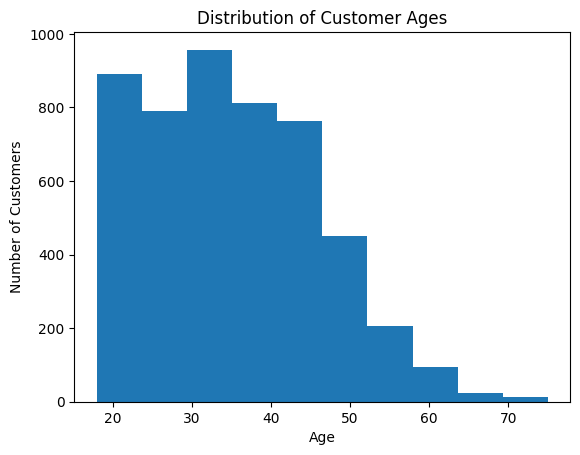

The average age is: 35.0326


In [32]:

df['Age'].mean()


import matplotlib.pyplot as plt

avg_age = df['Age'].mean()


plt.figure()
plt.hist(df['Age'], bins=10)
plt.title("Distribution of Customer Ages")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

print('The average age is:', avg_age)


#### 4.What is the total sales generated?

In [33]:
sale = df['Total_Sales'].sum()

print ('The total sales generated :', sale)

The total sales generated : 4915544.57


#### 5.Which city has the highest number of sales?

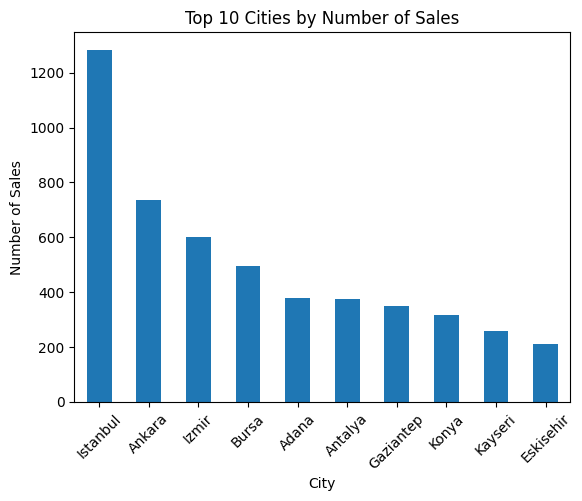

City with highest sales: Istanbul
Number of sales: 1284


In [ ]:

city_sales = df['City'].value_counts()

top_city = city_sales.idxmax()
top_sales = city_sales.max()

city_sales.head(10).plot(kind='bar')
plt.title("Top 10 Cities by Number of Sales")
plt.xlabel("City")
plt.ylabel("Number of Sales")
plt.xticks(rotation=45)
plt.show()

print("City with highest sales:", top_city)
print("Number of sales:", top_sales)

#### 6.Which product category generates the highest revenue?

Product_Category
Electronics      2328806.81
Home & Garden     908348.86
Sports            754563.56
Fashion           375214.93
Toys              223142.48
Beauty            156584.74
Food               96138.67
Books              72744.52
Name: Total_Sales, dtype: float64


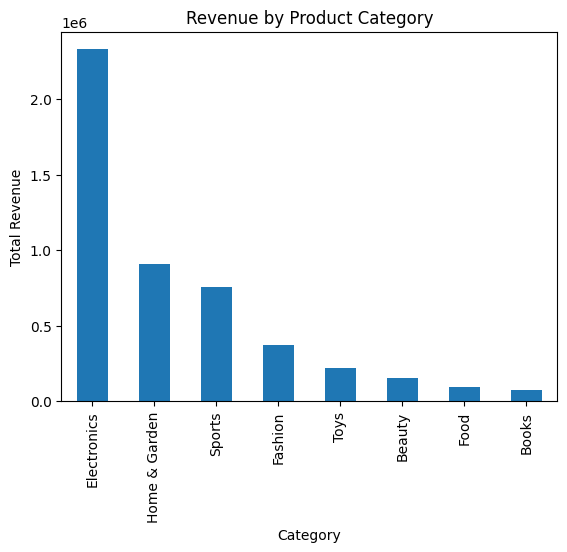

Electronics have the highest revenue


In [ ]:
category_revenue = df.groupby('Product_Category')['Total_Sales'].sum().sort_values(ascending=False)
print(category_revenue)

category_revenue.plot(kind='bar')
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.show()

print("Electronics have the highest revenue")

#### 7. which payment method is most used

Payment_Method
Credit Card         2012
Debit Card          1265
Digital Wallet       965
Bank Transfer        510
Cash on Delivery     248
Name: count, dtype: int64


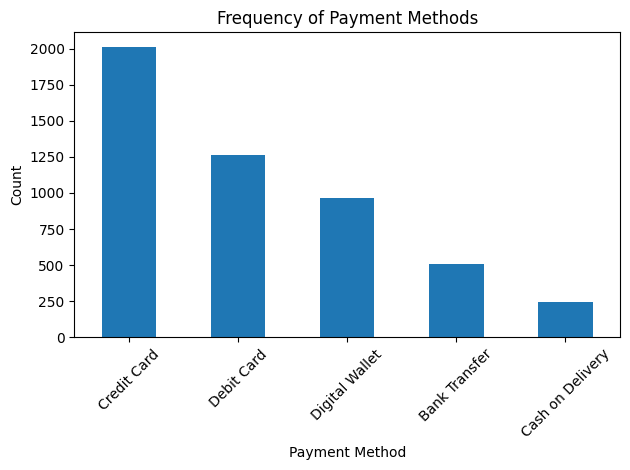

The most used payment method is: Credit Card


In [34]:
payment_counts=df['Payment_Method'].value_counts()
print(payment_counts)

payment_counts.plot(kind='bar')
plt.title('Frequency of Payment Methods')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()
print("The most used payment method is:", payment_counts.idxmax())

#### 8.Which product category has the highest average rating?

Product_Category
Books            3.967532
Home & Garden    3.938808
Electronics      3.919872
Beauty           3.908213
Sports           3.898051
Toys             3.883607
Name: Customer_Rating, dtype: float64


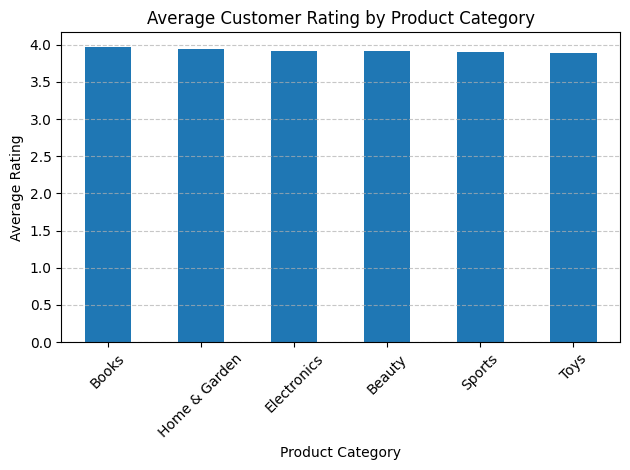

Product category with highest average rating: Books


In [29]:
avg_ratings=df.groupby('Product_Category')['Customer_Rating'].mean().sort_values(ascending=False).head(6)
print(avg_ratings)
avg_ratings.plot(kind='bar')
plt.title('Average Customer Rating by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print('Product category with highest average rating:',avg_ratings.idxmax())

#### 9.Top 5 customers by total spending

Customer_Id
CUST_04705    22023.90
CUST_00061    21478.35
CUST_01984    21409.05
CUST_00525    20211.81
CUST_03721    19547.20
Name: Total_Sales, dtype: float64


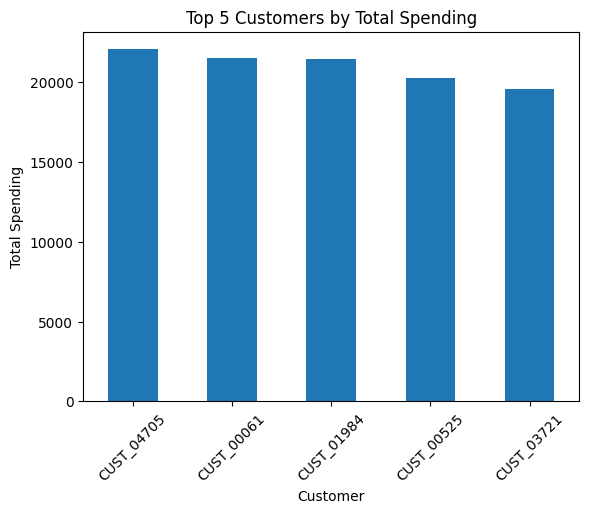

In [20]:
top_customers = (
    df.groupby('Customer_Id')['Total_Sales']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)
                                                                                                
print(top_customers)
plt.figure()
top_customers.plot(kind='bar')
plt.xlabel('Customer')
plt.ylabel('Total Spending')
plt.title('Top 5 Customers by Total Spending')
plt.xticks(rotation=45)
plt.show()

#### 10. How many male and female customers are there?

Gender
Female    2492
Male      2435
Name: count, dtype: int64


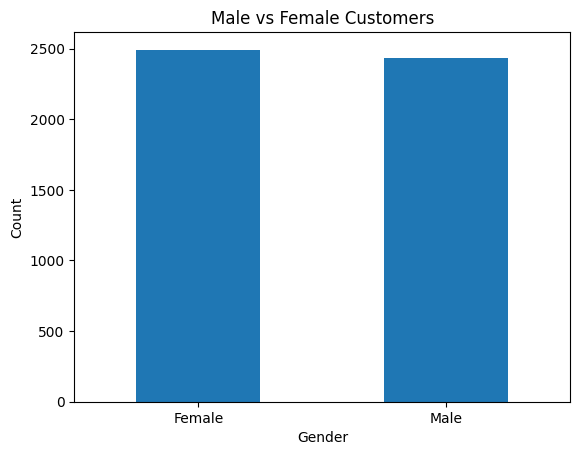

In [21]:
gender_counts=df['Gender'].value_counts().head(2)
print(gender_counts)

plt.figure()
gender_counts.plot(kind='bar')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Male vs Female Customers')
plt.xticks(rotation=0)
plt.show()

There are 2492 female customers and 2435 male customers

#### 11.Compare revenue with and without discount

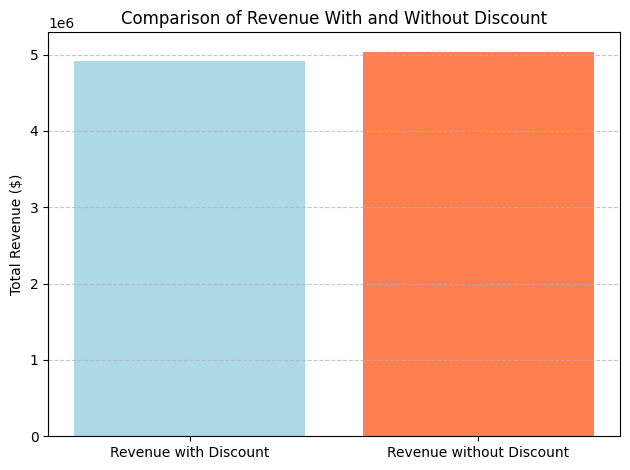

In [22]:
total_rev_with_discount = df['Total_Sales'].sum()
total_rev_without_discount = df['Revenue_Without_Discount'].sum()

categories = ['Revenue with Discount', 'Revenue without Discount']
values = [total_rev_with_discount, total_rev_without_discount]

plt.bar(categories, values, color=['lightblue', 'coral'])
plt.title('Comparison of Revenue With and Without Discount')
plt.ylabel('Total Revenue ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

Products without discount produces more revenue

#### 12.How many returning vs new customers?

In [23]:
df['Is_Returning_Customer'].value_counts()

Is_Returning_Customer
True     2990
False    2010
Name: count, dtype: int64

There are 2990 returning customers and 2010 new customers

### Conclusion





In this project, Exploratory Data Analysis (EDA) was performed to understand the structure, patterns, and key insights within the dataset. By applying various statistical techniques and visualizations, we were able to identify trends, relationships, and anomalies in the data.

Through this project, it became clear how data-driven decision-making can help businesses improve sales strategies, enhance customer experience, and increase overall profitability. Identifying high-revenue categories and top customers allows companies to focus their marketing efforts more efficiently.

The analysis revealed important insights such as customer behavior patterns, distribution of key variables, and factors influencing outcomes. Data cleaning and preprocessing played a crucial role in ensuring the accuracy and reliability of the results. Visual representations like charts and graphs helped in simplifying complex information and making it easier to interpret.

Overall, this project demonstrates the importance of data analysis in real-world applications and highlights how EDA serves as a crucial first step in any data science or business analytics workflow.


Thankyou
